In [1]:
import pandas as pd


df = pd.read_csv("/app/data/yash-m2m/Data/full_data_table.csv", index_col=0)
df.head()

,chosen_exam,array,gender,age_diag,grade,cancer_history,ajcc_path_tumor_pt,ajcc_path_nodes_pn,ajcc_clin_metastasis_cm,ajcc_path_metastasis_pm,...,Func_MAX,Func_HIST1H2BM,Func_EME2,Func_CELA1,Func_FRG2B,Func_GPRC6A,TMB_Count,TMB_Value,class_labels,class_labels_MYC_V2_median
TCGA-A3-3311,TCGA-A3-3311-01A-01-BS1.npz,[[0.09420455 0.00782806 0.01335143 ... 0.00516...,1,4.0,2,NaN,1,0,-1,1,...,WT,WT,WT,WT,WT,WT,57,0.000002,NON_ccA/B,above_median
TCGA-A3-3316,TCGA-A3-3316-11A-01-BS1.npz,[[0.08240734 0.00747561 0.01144183 ... 0.00945...,1,4.0,3,NaN,4,0,-1,1,...,WT,WT,WT,WT,WT,WT,43,0.000002,ccB_only,below_median
TCGA-A3-3317,TCGA-A3-3317-01A-02-BS2.npz,[[0.08040426 0.01684249 0.0070834 ... 0.00849...,1,5.0,2,NaN,4,1,-1,1,...,WT,WT,WT,WT,WT,WT,61,0.000002,ccB_only,above_median
TCGA-A3-3320,TCGA-A3-3320-01A-01-BS1.npz,[[0.09117609 0.00739556 0.01012404 ... 0.00628...,0,4.0,1,NaN,3,0,-1,1,...,WT,WT,WT,WT,WT,WT,75,0.000003,ccA_only,below_median
TCGA-A3-3322,TCGA-A3-3322-11A-01-TS1.npz,[[0.07906659 0.01137321 0.00670323 ... 0.00638...,1,4.0,2,NaN,2,0,-1,1,...,WT,WT,WT,WT,WT,WT,48,0.000002,ccA_only,below_median


# Gene selection

In [2]:
# Gene selection setup (multiclass target: class_labels)
target_col = "class_labels"
allowed_labels = [
    "NON_ccA/B",
    "ccB_only",
    "ccA_only",
    "SHARED_ccA/B",
]

gene_data_cols = [c for c in df.columns if c.startswith("Func_") or c == "TMB_Count"]

if target_col not in df.columns:
    raise KeyError("Missing target column 'class_labels' in df.")

gene_data = df[gene_data_cols + [target_col]].copy()
unexpected = set(gene_data[target_col].dropna().astype(str).unique()) - set(allowed_labels)
if unexpected:
    raise ValueError(f"Unexpected {target_col} values: {unexpected}")

print("gene feature columns:", len(gene_data_cols))
print(gene_data_cols)
print(f"\nTarget ({target_col}) distribution:")
print(gene_data[target_col].value_counts(dropna=False))

gene_data.head()

gene feature columns: 165
['Func_MSR1', 'Func_MUC4', 'Func_PTEN', 'Func_VHL', 'Func_CERCAM', 'Func_PBRM1', 'Func_PLEKHA2', 'Func_SETD2', 'Func_CD300E', 'Func_ANKRD36', 'Func_BAP1', 'Func_CHIT1', 'Func_ZNF304', 'Func_ARID1A', 'Func_GRIN3B', 'Func_NREP', 'Func_SYT15', 'Func_TXLNA', 'Func_ARHGEF25', 'Func_CCNB2', 'Func_SERPINB13', 'Func_PCK1', 'Func_FMN2', 'Func_LCN1', 'Func_MTOR', 'Func_ANKRD12', 'Func_OR4M2', 'Func_PIK3CA', 'Func_POC1B', 'Func_YLPM1', 'Func_AGAP6', 'Func_COL6A6', 'Func_KMT2C', 'Func_L1TD1', 'Func_TFDP2', 'Func_DIXDC1', 'Func_MAK16', 'Func_CPLX2', 'Func_IPP', 'Func_KRTAP4-9', 'Func_COL5A3', 'Func_PDE4C', 'Func_GATA2', 'Func_KDM5C', 'Func_KRTAP5-5', 'Func_MCPH1', 'Func_PABPC3', 'Func_RALGAPA1', 'Func_MSLNL', 'Func_PABPC1', 'Func_OR2T35', 'Func_RHEB', 'Func_DPPA2', 'Func_NEFH', 'Func_BTNL3', 'Func_C1orf52', 'Func_HLA-DRB5', 'Func_CRIPAK', 'Func_OVGP1', 'Func_TMEM255B', 'Func_MAP2K3', 'Func_POTED', 'Func_TRIP12', 'Func_ATM', 'Func_GINS3', 'Func_DHX37', 'Func_MAP7D1', 'Func_

,Func_MSR1,Func_MUC4,Func_PTEN,Func_VHL,Func_CERCAM,Func_PBRM1,Func_PLEKHA2,Func_SETD2,Func_CD300E,Func_ANKRD36,...,Func_FAM209A,Func_VCX2,Func_MAX,Func_HIST1H2BM,Func_EME2,Func_CELA1,Func_FRG2B,Func_GPRC6A,TMB_Count,class_labels
TCGA-A3-3311,WT,WT,WT,WT,WT,WT,LOF,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,WT,57,NON_ccA/B
TCGA-A3-3316,WT,WT,WT,WT,WT,LOF,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,WT,43,ccB_only
TCGA-A3-3317,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,WT,61,ccB_only
TCGA-A3-3320,WT,WT,WT,WT,WT,LOF,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,WT,75,ccA_only
TCGA-A3-3322,WT,WT,WT,WT,WT,LOF,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,WT,48,ccA_only


## All gene data (multiclass target: class_labels)

In [3]:
# ML model (multiclass) — adapted from binary pipeline
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve


def multiclass_macro_auc(y_true, y_prob, class_order):
    y_true = pd.Series(y_true).astype(str)
    y_bin = pd.get_dummies(y_true).reindex(columns=class_order, fill_value=0)
    if y_bin.sum(axis=0).min() == 0:
        return float("nan")
    return roc_auc_score(
        y_bin.values,
        y_prob,
        multi_class="ovr",
        average="macro",
    )


func_cols = [c for c in gene_data_cols if c.startswith("Func_")]
class_order = allowed_labels.copy()

gene_data_mod = gene_data.copy()
for c in func_cols:
    gene_data_mod[c] = gene_data_mod[c].map({"WT": 0, "LOF": 1})
gene_data_mod = gene_data_mod.dropna()

X = gene_data_mod[gene_data_cols]
y = gene_data_mod[target_col].astype(str)
print("class distribution:", y.value_counts(normalize=True).to_dict())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=123
)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

cv_logit_acc, cv_logit_f1 = [], []
cv_rf_acc, cv_rf_f1 = [], []
all_logit_probs, all_logit_obs = [], []
all_rf_probs, all_rf_obs = [], []

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    nv_func = [c for c in func_cols if X_tr[c].nunique() > 1]
    fold_cols = ["TMB_Count"] + nv_func
    X_tr_fold = X_tr[fold_cols]
    X_val_fold = X_val[fold_cols]

    logit = LogisticRegression(
        C=1e10,
        max_iter=2000,
        random_state=123,
        solver="lbfgs",
        multi_class="multinomial",
    )
    logit.fit(X_tr_fold, y_tr)
    logit_preds = logit.predict(X_val_fold)
    logit_proba_df = pd.DataFrame(
        logit.predict_proba(X_val_fold),
        index=X_val_fold.index,
        columns=logit.classes_,
    ).reindex(columns=class_order, fill_value=0.0)

    cv_logit_acc.append(accuracy_score(y_val, logit_preds))
    cv_logit_f1.append(f1_score(y_val, logit_preds, average="macro", zero_division=0))
    all_logit_probs.extend(logit_proba_df.to_numpy().tolist())
    all_logit_obs.extend(y_val.tolist())

    n_fold_features = len(fold_cols)
    rf = RandomForestClassifier(
        n_estimators=500,
        max_features=max(1, math.floor(math.sqrt(n_fold_features))),
        random_state=123,
    )
    rf.fit(X_tr_fold, y_tr)
    rf_preds = rf.predict(X_val_fold)
    rf_proba_df = pd.DataFrame(
        rf.predict_proba(X_val_fold),
        index=X_val_fold.index,
        columns=rf.classes_,
    ).reindex(columns=class_order, fill_value=0.0)

    cv_rf_acc.append(accuracy_score(y_val, rf_preds))
    cv_rf_f1.append(f1_score(y_val, rf_preds, average="macro", zero_division=0))
    all_rf_probs.extend(rf_proba_df.to_numpy().tolist())
    all_rf_obs.extend(y_val.tolist())

all_logit_probs_arr = np.array(all_logit_probs)
all_rf_probs_arr = np.array(all_rf_probs)

logit_auc_pooled = multiclass_macro_auc(all_logit_obs, all_logit_probs_arr, class_order)
rf_auc_pooled = multiclass_macro_auc(all_rf_obs, all_rf_probs_arr, class_order)

print(f"Logit CV acc        {np.mean(cv_logit_acc):.3f}")
print(f"Logit CV macro-F1   {np.mean(cv_logit_f1):.3f}")
print(f"Logit OOF macro-AUC {logit_auc_pooled:.3f}")
print(f"RF CV acc           {np.mean(cv_rf_acc):.3f}")
print(f"RF CV macro-F1      {np.mean(cv_rf_f1):.3f}")
print(f"RF OOF macro-AUC    {rf_auc_pooled:.3f}")

final_logit = LogisticRegression(
    C=1e10,
    max_iter=2000,
    random_state=123,
    solver="lbfgs",
    multi_class="multinomial",
)
final_logit.fit(X_train, y_train)
test_logit_preds = final_logit.predict(X_test)
test_logit_probs = pd.DataFrame(
    final_logit.predict_proba(X_test),
    index=X_test.index,
    columns=final_logit.classes_,
).reindex(columns=class_order, fill_value=0.0)

print(f"\nTest Logit acc      {accuracy_score(y_test, test_logit_preds):.3f}")
print(f"Test Logit macro-F1 {f1_score(y_test, test_logit_preds, average='macro', zero_division=0):.3f}")
print(f"Test Logit macro-AUC {multiclass_macro_auc(y_test, test_logit_probs.to_numpy(), class_order):.3f}")

final_rf = RandomForestClassifier(
    n_estimators=500,
    max_features=max(1, math.floor(math.sqrt(len(gene_data_cols)))),
    random_state=123,
)
final_rf.fit(X_train, y_train)
test_rf_preds = final_rf.predict(X_test)
test_rf_probs = pd.DataFrame(
    final_rf.predict_proba(X_test),
    index=X_test.index,
    columns=final_rf.classes_,
).reindex(columns=class_order, fill_value=0.0)

print(f"Test RF acc         {accuracy_score(y_test, test_rf_preds):.3f}")
print(f"Test RF macro-F1    {f1_score(y_test, test_rf_preds, average='macro', zero_division=0):.3f}")
print(f"Test RF macro-AUC   {multiclass_macro_auc(y_test, test_rf_probs.to_numpy(), class_order):.3f}")

class distribution: {'ccB_only': 0.4179566563467492, 'ccA_only': 0.4117647058823529, 'SHARED_ccA/B': 0.08978328173374613, 'NON_ccA/B': 0.0804953560371517}


/root/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logit CV acc        0.407
Logit CV macro-F1   0.231
Logit OOF macro-AUC 0.470
RF CV acc           0.477
RF CV macro-F1      0.310
RF OOF macro-AUC    0.596

Test Logit acc      0.538
Test Logit macro-F1 0.305
Test Logit macro-AUC 0.608
Test RF acc         0.354
Test RF macro-F1    0.228
Test RF macro-AUC   0.460


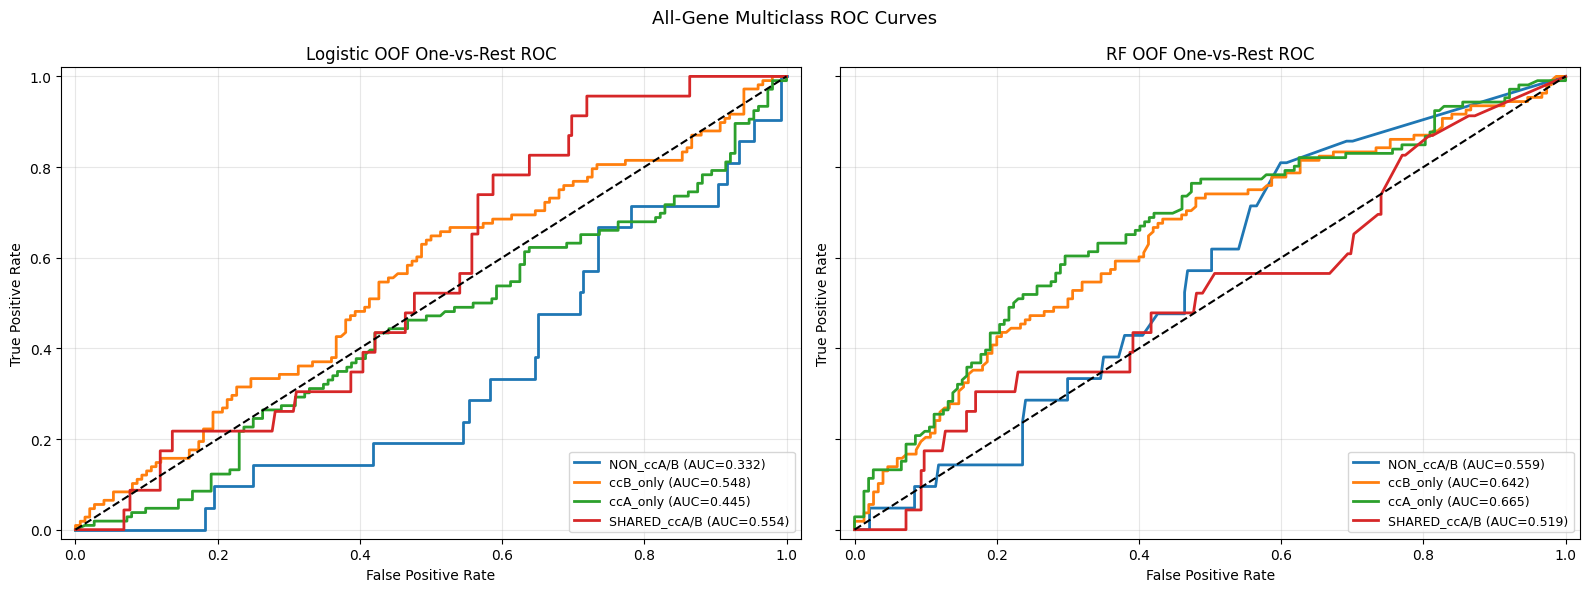

In [4]:
# Plot OOF one-vs-rest ROC curves for all-genes model
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

y_bin_logit = pd.get_dummies(pd.Series(all_logit_obs)).reindex(columns=class_order, fill_value=0).values
y_bin_rf = pd.get_dummies(pd.Series(all_rf_obs)).reindex(columns=class_order, fill_value=0).values

for i, cls in enumerate(class_order):
    fpr_l, tpr_l, _ = roc_curve(y_bin_logit[:, i], all_logit_probs_arr[:, i])
    auc_l = roc_auc_score(y_bin_logit[:, i], all_logit_probs_arr[:, i])
    axes[0].plot(fpr_l, tpr_l, lw=2, label=f"{cls} (AUC={auc_l:.3f})")

    fpr_r, tpr_r, _ = roc_curve(y_bin_rf[:, i], all_rf_probs_arr[:, i])
    auc_r = roc_auc_score(y_bin_rf[:, i], all_rf_probs_arr[:, i])
    axes[1].plot(fpr_r, tpr_r, lw=2, label=f"{cls} (AUC={auc_r:.3f})")

for ax, title in zip(axes, ["Logistic OOF One-vs-Rest ROC", "RF OOF One-vs-Rest ROC"]):
    ax.plot([0, 1], [0, 1], "k--", lw=1.5)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

plt.suptitle("All-Gene Multiclass ROC Curves", fontsize=13)
plt.tight_layout()
plt.show()

## Subset of genes from R scripts (multiclass target)

In [5]:
# Model on 21 R-selected features (multiclass)
from sklearn.model_selection import StratifiedKFold, train_test_split

selected_features = [
    "TMB_Count",
    "Func_MEGF6",
    "Func_ATG7",
    "Func_POLDIP2",
    "Func_COL5A3",
    "Func_MSLNL",
    "Func_SERPINB13",
    "Func_ST8SIA4",
    "Func_OR2T35",
    "Func_CHIT1",
    "Func_CASP5",
    "Func_TAS2R50",
    "Func_HOXC8",
    "Func_ARHGAP5",
    "Func_ANKRD36",
    "Func_SYT15",
    "Func_FAM209A",
    "Func_VCX3B",
    "Func_PTPRK",
    "Func_GATA2",
    "Func_CACYBP",
]

fs_data = df[selected_features + [target_col]].copy()
for c in selected_features:
    if c.startswith("Func_"):
        fs_data[c] = fs_data[c].map({"WT": 0, "LOF": 1})
fs_data = fs_data.dropna()

X_fs = fs_data[selected_features]
y_fs = fs_data[target_col].astype(str)

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(
    X_fs, y_fs, test_size=0.2, stratify=y_fs, random_state=123
)

skf_fs = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
cv_logit_acc_fs, cv_logit_f1_fs = [], []
cv_rf_acc_fs, cv_rf_f1_fs = [], []
all_logit_probs_fs, all_logit_obs_fs = [], []
all_rf_probs_fs, all_rf_obs_fs = [], []

for train_idx, val_idx in skf_fs.split(X_train_fs, y_train_fs):
    X_tr, X_val = X_train_fs.iloc[train_idx], X_train_fs.iloc[val_idx]
    y_tr, y_val = y_train_fs.iloc[train_idx], y_train_fs.iloc[val_idx]

    logit_fs = LogisticRegression(
        C=1e10,
        max_iter=2000,
        random_state=123,
        solver="lbfgs",
        multi_class="multinomial",
    )
    logit_fs.fit(X_tr, y_tr)
    logit_preds_fs = logit_fs.predict(X_val)
    logit_probs_fs = pd.DataFrame(
        logit_fs.predict_proba(X_val),
        index=X_val.index,
        columns=logit_fs.classes_,
    ).reindex(columns=class_order, fill_value=0.0)

    cv_logit_acc_fs.append(accuracy_score(y_val, logit_preds_fs))
    cv_logit_f1_fs.append(f1_score(y_val, logit_preds_fs, average="macro", zero_division=0))
    all_logit_probs_fs.extend(logit_probs_fs.to_numpy().tolist())
    all_logit_obs_fs.extend(y_val.tolist())

    rf_fs = RandomForestClassifier(
        n_estimators=500,
        max_features=max(1, math.floor(math.sqrt(len(selected_features)))),
        random_state=123,
    )
    rf_fs.fit(X_tr, y_tr)
    rf_preds_fs = rf_fs.predict(X_val)
    rf_probs_fs = pd.DataFrame(
        rf_fs.predict_proba(X_val),
        index=X_val.index,
        columns=rf_fs.classes_,
    ).reindex(columns=class_order, fill_value=0.0)

    cv_rf_acc_fs.append(accuracy_score(y_val, rf_preds_fs))
    cv_rf_f1_fs.append(f1_score(y_val, rf_preds_fs, average="macro", zero_division=0))
    all_rf_probs_fs.extend(rf_probs_fs.to_numpy().tolist())
    all_rf_obs_fs.extend(y_val.tolist())

all_logit_probs_fs_arr = np.array(all_logit_probs_fs)
all_rf_probs_fs_arr = np.array(all_rf_probs_fs)

logit_auc_pooled_fs = multiclass_macro_auc(all_logit_obs_fs, all_logit_probs_fs_arr, class_order)
rf_auc_pooled_fs = multiclass_macro_auc(all_rf_obs_fs, all_rf_probs_fs_arr, class_order)

print(f"Selected-features Logit CV acc        {np.mean(cv_logit_acc_fs):.3f}")
print(f"Selected-features Logit CV macro-F1   {np.mean(cv_logit_f1_fs):.3f}")
print(f"Selected-features Logit OOF macro-AUC {logit_auc_pooled_fs:.3f}")
print(f"Selected-features RF CV acc           {np.mean(cv_rf_acc_fs):.3f}")
print(f"Selected-features RF CV macro-F1      {np.mean(cv_rf_f1_fs):.3f}")
print(f"Selected-features RF OOF macro-AUC    {rf_auc_pooled_fs:.3f}")

final_logit_fs = LogisticRegression(
    C=1e10,
    max_iter=2000,
    random_state=123,
    solver="lbfgs",
    multi_class="multinomial",
)
final_logit_fs.fit(X_train_fs, y_train_fs)
test_logit_preds_fs = final_logit_fs.predict(X_test_fs)
test_logit_probs_fs = pd.DataFrame(
    final_logit_fs.predict_proba(X_test_fs),
    index=X_test_fs.index,
    columns=final_logit_fs.classes_,
).reindex(columns=class_order, fill_value=0.0)

print(f"\nTest Logit acc      {accuracy_score(y_test_fs, test_logit_preds_fs):.3f}")
print(f"Test Logit macro-F1 {f1_score(y_test_fs, test_logit_preds_fs, average='macro', zero_division=0):.3f}")
print(f"Test Logit macro-AUC {multiclass_macro_auc(y_test_fs, test_logit_probs_fs.to_numpy(), class_order):.3f}")

final_rf_fs = RandomForestClassifier(
    n_estimators=500,
    max_features=max(1, math.floor(math.sqrt(len(selected_features)))),
    random_state=123,
)
final_rf_fs.fit(X_train_fs, y_train_fs)
test_rf_preds_fs = final_rf_fs.predict(X_test_fs)
test_rf_probs_fs = pd.DataFrame(
    final_rf_fs.predict_proba(X_test_fs),
    index=X_test_fs.index,
    columns=final_rf_fs.classes_,
).reindex(columns=class_order, fill_value=0.0)

print(f"Test RF acc         {accuracy_score(y_test_fs, test_rf_preds_fs):.3f}")
print(f"Test RF macro-F1    {f1_score(y_test_fs, test_rf_preds_fs, average='macro', zero_division=0):.3f}")
print(f"Test RF macro-AUC   {multiclass_macro_auc(y_test_fs, test_rf_probs_fs.to_numpy(), class_order):.3f}")

Selected-features Logit CV acc        0.400
Selected-features Logit CV macro-F1   0.170
Selected-features Logit OOF macro-AUC 0.488
Selected-features RF CV acc           0.434
Selected-features RF CV macro-F1      0.271
Selected-features RF OOF macro-AUC    0.516

Test Logit acc      0.431
Test Logit macro-F1 0.180
Test Logit macro-AUC 0.503
Test RF acc         0.323
Test RF macro-F1    0.179
Test RF macro-AUC   0.489


## Feature selection using class_labels

In [6]:
from sklearn.metrics import mutual_info_score

# Leakage-safe setup: create one outer split and rank features using training data only
X_all = gene_data_mod[gene_data_cols]
y_all = gene_data_mod[target_col].astype(str)

X_outer_train, X_outer_test, y_outer_train, y_outer_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=123,
)

feature_count = min(50, X_outer_train.shape[1])


def _discretize_series(s: pd.Series, n_bins: int = 5) -> pd.Series:
    s = s.copy()

    if s.dropna().isin([0, 1]).all():
        return s.fillna(0).astype(int)

    if pd.api.types.is_numeric_dtype(s):
        non_na = s.dropna()
        if non_na.nunique() <= 2:
            return s.fillna(non_na.median() if len(non_na) else 0).astype(float).round().astype(int)
        try:
            binned = pd.qcut(non_na, q=min(n_bins, non_na.nunique()), labels=False, duplicates="drop")
            out = pd.Series(index=s.index, dtype=float)
            out.loc[non_na.index] = binned.astype(float)
            out = out.fillna(out.median() if out.notna().any() else 0)
            return out.astype(int)
        except Exception:
            return pd.factorize(s.fillna("__MISSING__").astype(str))[0]

    return pd.factorize(s.fillna("__MISSING__").astype(str))[0]


def run_python_mrmr_mid_multiclass(X_train_df: pd.DataFrame, y_train_series: pd.Series, n_features: int = 50):
    X_work = X_train_df.copy()

    y_num = pd.Categorical(y_train_series.astype(str), categories=class_order).codes

    for c in X_work.columns:
        if c.startswith("Func_"):
            X_work[c] = X_work[c].map({"WT": 0, "LOF": 1}).fillna(X_work[c])

    X_disc = pd.DataFrame({c: _discretize_series(X_work[c]) for c in X_work.columns}, index=X_work.index)

    relevance = pd.Series(
        {c: mutual_info_score(X_disc[c].astype(int), y_num.astype(int)) for c in X_disc.columns}
    )

    cols = list(X_disc.columns)
    redundancy = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)
    for i, ci in enumerate(cols):
        xi = X_disc[ci].astype(int)
        for j in range(i + 1, len(cols)):
            cj = cols[j]
            xj = X_disc[cj].astype(int)
            mi_ij = mutual_info_score(xi, xj)
            redundancy.loc[ci, cj] = mi_ij
            redundancy.loc[cj, ci] = mi_ij

    selected = []
    remaining = cols.copy()

    first = relevance.sort_values(ascending=False).index[0]
    selected.append(first)
    remaining.remove(first)

    while len(selected) < n_features and remaining:
        scores = {}
        for c in remaining:
            red = redundancy.loc[c, selected].mean() if selected else 0.0
            scores[c] = relevance[c] - red

        score_series = pd.Series(scores)
        best_score = score_series.max()
        tied = score_series[score_series == best_score].index.tolist()
        if len(tied) > 1:
            tied = sorted(tied, key=lambda k: (-relevance[k], k))
        best = tied[0]

        selected.append(best)
        remaining.remove(best)

    return selected


selected_mrmr_features = run_python_mrmr_mid_multiclass(
    X_outer_train,
    y_outer_train,
    n_features=feature_count,
)

mrmr_backend = "Python standalone mRMR-MID (multiclass)"
print(f"mRMR backend used: {mrmr_backend}")
print("Selected features (top", feature_count, ") from outer-train split:")
print(selected_mrmr_features)
print(f"Outer-train shape: {X_outer_train.shape}, outer-test shape: {X_outer_test.shape}")

mRMR backend used: Python standalone mRMR-MID (multiclass)
Selected features (top 50 ) from outer-train split:
['Func_PBRM1', 'Func_VHL', 'Func_PTEN', 'Func_COL11A1', 'Func_ATM', 'Func_IVL', 'Func_PLEKHA2', 'Func_NEFH', 'Func_NF2', 'Func_ASIC2', 'Func_MSLNL', 'Func_KLK13', 'Func_HLA-DRB5', 'Func_ALDOB', 'TMB_Count', 'Func_BAP1', 'Func_OR4M2', 'Func_OVGP1', 'Func_PABPC1', 'Func_SCAF1', 'Func_COL6A6', 'Func_IPP', 'Func_LMOD3', 'Func_OR5P2', 'Func_DNAJC14', 'Func_ANKRD12', 'Func_POLDIP2', 'Func_ANKRD36', 'Func_SERPINB13', 'Func_ARFGEF2', 'Func_CACYBP', 'Func_L1TD1', 'Func_COL5A3', 'Func_SYT15', 'Func_TYRO3', 'Func_CLRN3', 'Func_GOT1', 'Func_JMJD6', 'Func_PROS1', 'Func_MUC4', 'Func_ARID1A', 'Func_ZNF717', 'Func_KDM5C', 'Func_DHX37', 'Func_HOXC8', 'Func_PCK1', 'Func_MAX', 'Func_MCPH1', 'Func_NDUFC1', 'Func_UBXN11']
Outer-train shape: (258, 165), outer-test shape: (65, 165)


In [7]:
# Top-k feature scan (multiclass)
results = []

for k in range(1, len(selected_mrmr_features) + 1):
    features_k = selected_mrmr_features[:k]
    X_train_k = X_outer_train[features_k]

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
    cv_logit_f1, cv_rf_f1 = [], []
    all_logit_probs_k, all_logit_obs_k = [], []
    all_rf_probs_k, all_rf_obs_k = [], []

    for train_idx, val_idx in skf.split(X_train_k, y_outer_train):
        X_tr = X_train_k.iloc[train_idx]
        X_val = X_train_k.iloc[val_idx]
        y_tr = y_outer_train.iloc[train_idx]
        y_val = y_outer_train.iloc[val_idx]

        logit = LogisticRegression(
            C=1e10,
            max_iter=2000,
            random_state=123,
            solver="lbfgs",
            multi_class="multinomial",
        )
        logit.fit(X_tr, y_tr)
        y_pred_logit = logit.predict(X_val)
        y_prob_logit = pd.DataFrame(
            logit.predict_proba(X_val),
            index=X_val.index,
            columns=logit.classes_,
        ).reindex(columns=class_order, fill_value=0.0)

        cv_logit_f1.append(f1_score(y_val, y_pred_logit, average="macro", zero_division=0))
        all_logit_probs_k.extend(y_prob_logit.to_numpy().tolist())
        all_logit_obs_k.extend(y_val.tolist())

        rf = RandomForestClassifier(
            n_estimators=500,
            max_features=max(1, math.floor(math.sqrt(k))),
            random_state=123,
        )
        rf.fit(X_tr, y_tr)
        y_pred_rf = rf.predict(X_val)
        y_prob_rf = pd.DataFrame(
            rf.predict_proba(X_val),
            index=X_val.index,
            columns=rf.classes_,
        ).reindex(columns=class_order, fill_value=0.0)

        cv_rf_f1.append(f1_score(y_val, y_pred_rf, average="macro", zero_division=0))
        all_rf_probs_k.extend(y_prob_rf.to_numpy().tolist())
        all_rf_obs_k.extend(y_val.tolist())

    logit_auc = multiclass_macro_auc(all_logit_obs_k, np.array(all_logit_probs_k), class_order)
    rf_auc = multiclass_macro_auc(all_rf_obs_k, np.array(all_rf_probs_k), class_order)

    results.append(
        {
            "k": k,
            "logit_f1": np.mean(cv_logit_f1),
            "logit_auc": logit_auc,
            "rf_f1": np.mean(cv_rf_f1),
            "rf_auc": rf_auc,
        }
    )

results_df = pd.DataFrame(results)

best_logit_f1_idx = results_df["logit_f1"].idxmax()
best_logit_auc_idx = results_df["logit_auc"].idxmax()
best_rf_f1_idx = results_df["rf_f1"].idxmax()
best_rf_auc_idx = results_df["rf_auc"].idxmax()

k_best_logit_f1 = int(results_df.loc[best_logit_f1_idx, "k"])
k_best_logit_auc = int(results_df.loc[best_logit_auc_idx, "k"])
k_best_rf_f1 = int(results_df.loc[best_rf_f1_idx, "k"])
k_best_rf_auc = int(results_df.loc[best_rf_auc_idx, "k"])

best_summary = pd.DataFrame(
    {
        "model": ["Logistic", "Logistic", "RF", "RF"],
        "metric": ["Macro-F1", "Macro-AUC", "Macro-F1", "Macro-AUC"],
        "best_k": [k_best_logit_f1, k_best_logit_auc, k_best_rf_f1, k_best_rf_auc],
        "best_value": [
            results_df.loc[best_logit_f1_idx, "logit_f1"],
            results_df.loc[best_logit_auc_idx, "logit_auc"],
            results_df.loc[best_rf_f1_idx, "rf_f1"],
            results_df.loc[best_rf_auc_idx, "rf_auc"],
        ],
    }
)
print(best_summary.to_string(index=False))


def evaluate_on_holdout_multiclass(features):
    X_tr = X_outer_train[features]
    X_te = X_outer_test[features]

    logit = LogisticRegression(
        C=1e10,
        max_iter=2000,
        random_state=123,
        solver="lbfgs",
        multi_class="multinomial",
    )
    logit.fit(X_tr, y_outer_train)
    lp = logit.predict(X_te)
    lprob = pd.DataFrame(
        logit.predict_proba(X_te),
        index=X_te.index,
        columns=logit.classes_,
    ).reindex(columns=class_order, fill_value=0.0)

    rf = RandomForestClassifier(
        n_estimators=500,
        max_features=max(1, math.floor(math.sqrt(len(features)))),
        random_state=123,
    )
    rf.fit(X_tr, y_outer_train)
    rp = rf.predict(X_te)
    rprob = pd.DataFrame(
        rf.predict_proba(X_te),
        index=X_te.index,
        columns=rf.classes_,
    ).reindex(columns=class_order, fill_value=0.0)

    return (
        accuracy_score(y_outer_test, lp),
        f1_score(y_outer_test, lp, average="macro", zero_division=0),
        multiclass_macro_auc(y_outer_test, lprob.to_numpy(), class_order),
        accuracy_score(y_outer_test, rp),
        f1_score(y_outer_test, rp, average="macro", zero_division=0),
        multiclass_macro_auc(y_outer_test, rprob.to_numpy(), class_order),
    )


print("\nHoldout test metrics at best-k values:")
for label, k_val in [
    ("Logistic Macro-F1", k_best_logit_f1),
    ("Logistic Macro-AUC", k_best_logit_auc),
    ("RF Macro-F1", k_best_rf_f1),
    ("RF Macro-AUC", k_best_rf_auc),
]:
    la, lf, lauc, ra, rf1, rauc = evaluate_on_holdout_multiclass(selected_mrmr_features[:k_val])
    print(
        f"  k={k_val:2d} (best by {label}): "
        f"Logit ACC={la:.3f} F1={lf:.3f} AUC={lauc:.3f} | "
        f"RF ACC={ra:.3f} F1={rf1:.3f} AUC={rauc:.3f}"
    )

logit_best_f1 = results_df.loc[best_logit_f1_idx, "logit_f1"]
rf_best_f1 = results_df.loc[best_rf_f1_idx, "rf_f1"]
if logit_best_f1 >= rf_best_f1:
    best_k_for_multimodal = k_best_logit_f1
    best_k_source = f"Logistic Macro-F1 (k={k_best_logit_f1}, F1={logit_best_f1:.3f})"
else:
    best_k_for_multimodal = k_best_rf_f1
    best_k_source = f"RF Macro-F1 (k={k_best_rf_f1}, F1={rf_best_f1:.3f})"

print(f"\nBest k for multimodal section: k={best_k_for_multimodal} [{best_k_source}]")

/root/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/root/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i 

   model    metric  best_k  best_value
Logistic  Macro-F1      15    0.304729
Logistic Macro-AUC      15    0.560722
      RF  Macro-F1      16    0.318204
      RF Macro-AUC      16    0.633418

Holdout test metrics at best-k values:
  k=15 (best by Logistic Macro-F1): Logit ACC=0.523 F1=0.287 AUC=0.573 | RF ACC=0.323 F1=0.188 AUC=0.499
  k=15 (best by Logistic Macro-AUC): Logit ACC=0.523 F1=0.287 AUC=0.573 | RF ACC=0.323 F1=0.188 AUC=0.499
  k=16 (best by RF Macro-F1): Logit ACC=0.523 F1=0.286 AUC=0.584 | RF ACC=0.308 F1=0.205 AUC=0.478
  k=16 (best by RF Macro-AUC): Logit ACC=0.523 F1=0.286 AUC=0.584 | RF ACC=0.308 F1=0.205 AUC=0.478

Best k for multimodal section: k=16 [RF Macro-F1 (k=16, F1=0.318)]


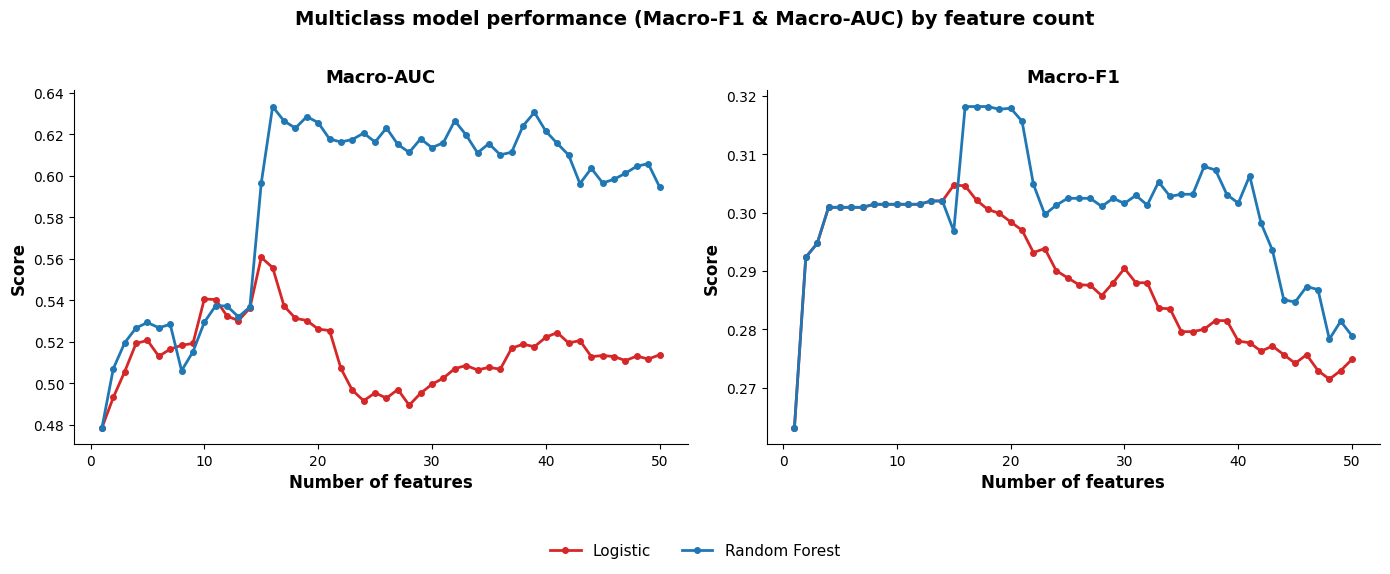

In [8]:
# Plot top-k multiclass performance curves
results_long = results_df.melt(
    id_vars=["k"],
    value_vars=["logit_f1", "logit_auc", "rf_f1", "rf_auc"],
    var_name="metric_model",
    value_name="score",
)
results_long[["model", "metric"]] = results_long["metric_model"].str.split("_", expand=True)
results_long["model"] = results_long["model"].map({"logit": "Logistic", "rf": "Random Forest"})
results_long["metric"] = results_long["metric"].map({"f1": "Macro-F1", "auc": "Macro-AUC"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"Logistic": "#d62728", "Random Forest": "#1f77b4"}

for ax, metric in zip(axes, ["Macro-AUC", "Macro-F1"]):
    data_subset = results_long[results_long["metric"] == metric]
    for model in ["Logistic", "Random Forest"]:
        model_data = data_subset[data_subset["model"] == model]
        ax.plot(
            model_data["k"],
            model_data["score"],
            marker="o",
            linewidth=2,
            markersize=4,
            label=model,
            color=colors[model],
        )

    ax.set_xlabel("Number of features", fontsize=12, fontweight="bold")
    ax.set_ylabel("Score", fontsize=12, fontweight="bold")
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.grid(False)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.legend(
    ["Logistic", "Random Forest"],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    fontsize=11,
    frameon=False,
)

fig.suptitle("Multiclass model performance (Macro-F1 & Macro-AUC) by feature count", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

# Best-k genes + metadata + WSI array (multiclass)

Fit a multinomial random forest model using:

- best-k selected genes (k = feature count with highest CV Macro-F1 across Logistic and RF in top-k scan)
- patient metadata columns ('Split' removed)
- expanded WSI array values

Target: class_labels

In [9]:
from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

metadata_columns = [
    "gender",
    "age_diag",
    "grade",
    "cancer_history",
    "ajcc_path_tumor_pt",
    "ajcc_path_nodes_pn",
    "ajcc_clin_metastasis_cm",
    "ajcc_path_metastasis_pm",
    "ajcc_path_tumor_stage",
    "vital_status_12",
    "race_Asian",
    "race_Black or African American",
    "race_Hispanic or Latino",
    "race_White",
    "race_other",
    "VHL_mutation",
    "PBMR1_mutation",
    "TTN_mutation",
]

wsi_feature_dir = Path("/app/data/yash-m2m/Data/Features/WSI Features")

gene_k = best_k_for_multimodal
gene_columns_topk = selected_mrmr_features[:gene_k]
print(f"Using k={gene_k} genes (source: {best_k_source})")
print("Gene columns:", gene_columns_topk)

required_columns = gene_columns_topk + metadata_columns + ["chosen_exam", target_col]
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise KeyError(f"Missing expected columns: {missing_columns}")


def load_wsi_embedding(npz_name):
    npz_path = wsi_feature_dir / npz_name
    if not npz_path.exists():
        return None
    with np.load(npz_path) as data:
        embedding = np.ravel(data["arr_0"]).astype(float)
    return embedding


model_df = df[required_columns].copy()
for col in gene_columns_topk:
    if col.startswith("Func_"):
        model_df[col] = model_df[col].map({"WT": 0, "LOF": 1})

model_df["wsi_embedding"] = model_df["chosen_exam"].apply(load_wsi_embedding)
model_df = model_df.dropna(subset=[target_col, "wsi_embedding"]).copy()

embedding_lengths = model_df["wsi_embedding"].apply(len)
if embedding_lengths.nunique() != 1:
    raise ValueError(
        f"WSI embedding lengths are inconsistent: {embedding_lengths.value_counts().to_dict()}"
    )

wsi_array_df = pd.DataFrame(
    model_df["wsi_embedding"].tolist(),
    index=model_df.index,
).add_prefix("wsi_")

metadata_df = model_df[metadata_columns].apply(pd.to_numeric, errors="coerce")
gene_df = model_df[gene_columns_topk].apply(pd.to_numeric, errors="coerce")

raw_feature_df = pd.concat([gene_df, metadata_df, wsi_array_df], axis=1)
y_multimodal = model_df[target_col].astype(str)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    raw_feature_df,
    y_multimodal,
    test_size=0.2,
    stratify=y_multimodal,
    random_state=123,
)

logit_multi = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            RandomForestClassifier(
                n_estimators=500,
                max_features=max(1, math.floor(math.sqrt(raw_feature_df.shape[1]))),
                random_state=123,
            ),
        ),
    ]
)

skf_multi = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)
cv_acc_scores_multi, cv_f1_scores_multi = [], []
all_probs_multi, all_obs_multi = [], []

for train_idx, val_idx in skf_multi.split(X_train_multi, y_train_multi):
    X_tr = X_train_multi.iloc[train_idx]
    X_val = X_train_multi.iloc[val_idx]
    y_tr = y_train_multi.iloc[train_idx]
    y_val = y_train_multi.iloc[val_idx]

    logit_multi.fit(X_tr, y_tr)
    y_pred_multi = logit_multi.predict(X_val)
    y_prob_multi_df = pd.DataFrame(
        logit_multi.predict_proba(X_val),
        index=X_val.index,
        columns=logit_multi.named_steps["model"].classes_,
    ).reindex(columns=class_order, fill_value=0.0)

    cv_acc_scores_multi.append(accuracy_score(y_val, y_pred_multi))
    cv_f1_scores_multi.append(f1_score(y_val, y_pred_multi, average="macro", zero_division=0))
    all_probs_multi.extend(y_prob_multi_df.to_numpy().tolist())
    all_obs_multi.extend(y_val.tolist())

all_probs_multi_arr = np.array(all_probs_multi)
cv_auc_pooled_multi = multiclass_macro_auc(all_obs_multi, all_probs_multi_arr, class_order)

logit_multi.fit(X_train_multi, y_train_multi)
y_test_pred_multi = logit_multi.predict(X_test_multi)
y_test_prob_multi_df = pd.DataFrame(
    logit_multi.predict_proba(X_test_multi),
    index=X_test_multi.index,
    columns=logit_multi.named_steps["model"].classes_,
).reindex(columns=class_order, fill_value=0.0)

missing_wsi_files = int(model_df["wsi_embedding"].isna().sum())

topk_multimodal_results = pd.Series(
    {
        "target": target_col,
        "gene_k": gene_k,
        "gene_k_source": best_k_source,
        "n_samples": len(raw_feature_df),
        "n_features_total": raw_feature_df.shape[1],
        "n_gene_features": len(gene_columns_topk),
        "n_metadata_features": len(metadata_columns),
        "n_wsi_features": wsi_array_df.shape[1],
        "cv_accuracy": np.mean(cv_acc_scores_multi),
        "cv_macro_f1": np.mean(cv_f1_scores_multi),
        "cv_macro_auc_pooled_oof": cv_auc_pooled_multi,
        "test_accuracy": accuracy_score(y_test_multi, y_test_pred_multi),
        "test_macro_f1": f1_score(y_test_multi, y_test_pred_multi, average="macro", zero_division=0),
        "test_macro_auc": multiclass_macro_auc(y_test_multi, y_test_prob_multi_df.to_numpy(), class_order),
    }
)

print(f"Gene columns (k={gene_k}):", gene_columns_topk)
print("WSI embedding length:", wsi_array_df.shape[1])
print("Missing WSI files:", missing_wsi_files)
print("\nMulticlass multimodal RF results:")
topk_multimodal_results

Using k=16 genes (source: RF Macro-F1 (k=16, F1=0.318))
Gene columns: ['Func_PBRM1', 'Func_VHL', 'Func_PTEN', 'Func_COL11A1', 'Func_ATM', 'Func_IVL', 'Func_PLEKHA2', 'Func_NEFH', 'Func_NF2', 'Func_ASIC2', 'Func_MSLNL', 'Func_KLK13', 'Func_HLA-DRB5', 'Func_ALDOB', 'TMB_Count', 'Func_BAP1']
Gene columns (k=16): ['Func_PBRM1', 'Func_VHL', 'Func_PTEN', 'Func_COL11A1', 'Func_ATM', 'Func_IVL', 'Func_PLEKHA2', 'Func_NEFH', 'Func_NF2', 'Func_ASIC2', 'Func_MSLNL', 'Func_KLK13', 'Func_HLA-DRB5', 'Func_ALDOB', 'TMB_Count', 'Func_BAP1']
WSI embedding length: 1024
Missing WSI files: 0

Multiclass multimodal RF results:


target                                     class_labels
gene_k                                               16
gene_k_source              RF Macro-F1 (k=16, F1=0.318)
n_samples                                           323
n_features_total                                   1058
n_gene_features                                      16
n_metadata_features                                  18
n_wsi_features                                     1024
cv_accuracy                                    0.496154
cv_macro_f1                                    0.271498
cv_macro_auc_pooled_oof                        0.580787
test_accuracy                                  0.615385
test_macro_f1                                  0.336158
test_macro_auc                                 0.623291
dtype: object

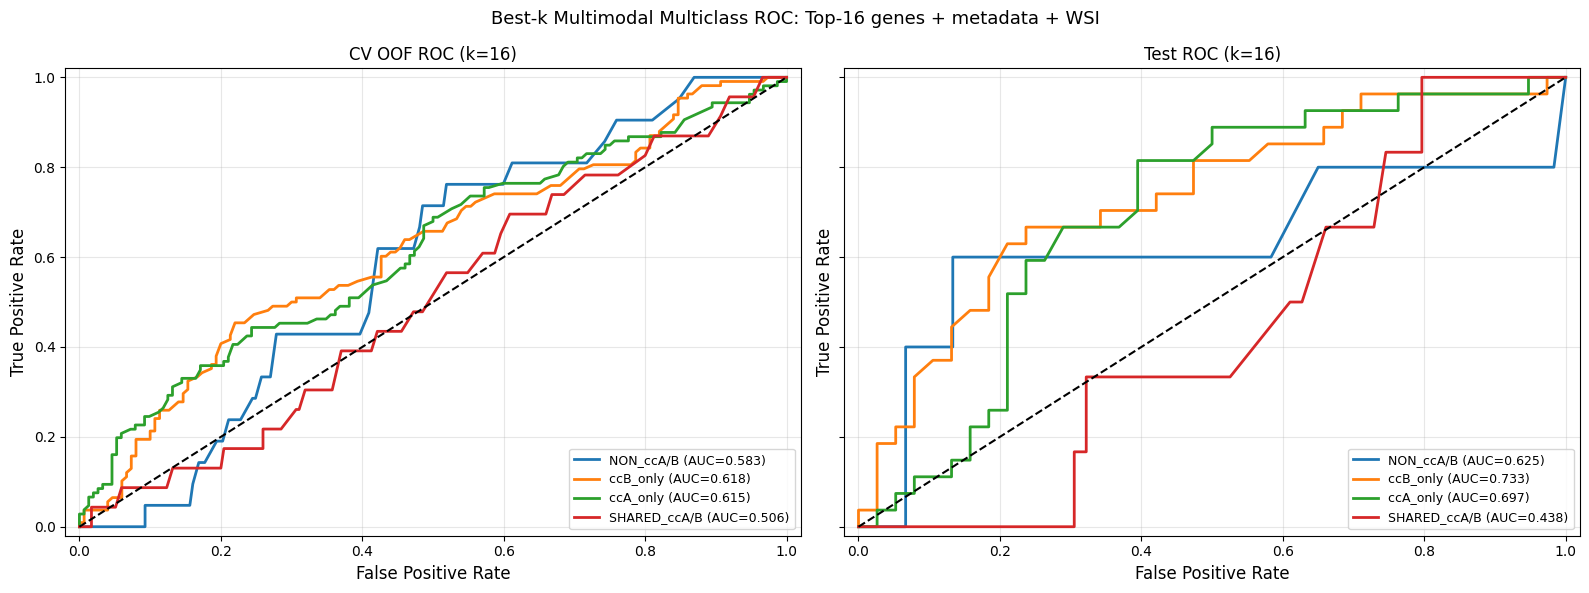

In [10]:
# Plot multiclass ROC curves for best-k multimodal model (CV pooled OOF + test set)
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)

y_bin_cv = pd.get_dummies(pd.Series(all_obs_multi)).reindex(columns=class_order, fill_value=0).values
y_bin_test = pd.get_dummies(pd.Series(y_test_multi)).reindex(columns=class_order, fill_value=0).values

for i, cls in enumerate(class_order):
    fpr_cv, tpr_cv, _ = roc_curve(y_bin_cv[:, i], all_probs_multi_arr[:, i])
    auc_cv = roc_auc_score(y_bin_cv[:, i], all_probs_multi_arr[:, i])
    axes[0].plot(fpr_cv, tpr_cv, lw=2, label=f"{cls} (AUC={auc_cv:.3f})")

    fpr_test, tpr_test, _ = roc_curve(y_bin_test[:, i], y_test_prob_multi_df.to_numpy()[:, i])
    auc_test = roc_auc_score(y_bin_test[:, i], y_test_prob_multi_df.to_numpy()[:, i])
    axes[1].plot(fpr_test, tpr_test, lw=2, label=f"{cls} (AUC={auc_test:.3f})")

for ax, title in zip(axes, [f"CV OOF ROC (k={gene_k})", f"Test ROC (k={gene_k})"]):
    ax.plot([0, 1], [0, 1], "k--", lw=1.5)
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate", fontsize=12)
    ax.set_title(title, fontsize=12)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.02])

plt.suptitle(f"Best-k Multimodal Multiclass ROC: Top-{gene_k} genes + metadata + WSI", fontsize=13)
plt.tight_layout()
plt.show()